In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

base_dir = "/content/drive/MyDrive/CS289A/project"

# copy the two HAM10000 zip files and the trained model to local Colab storage
!cp "$base_dir/HAM10000_images_part_1.zip" /content/
!cp "$base_dir/HAM10000_images_part_2.zip" /content/
!cp "$base_dir/segmentation_unet_v2.pth" /content/

# create a folder for all HAM10000 images
os.makedirs("/content/HAM10000_images", exist_ok=True)

# unzip both parts into the same folder
!unzip -q -o /content/HAM10000_images_part_1.zip -d /content/HAM10000_images
!unzip -q -o /content/HAM10000_images_part_2.zip -d /content/HAM10000_images

In [3]:
image_dir = "/content/HAM10000_images"

all_files = sorted(os.listdir(image_dir))

print("Number of files:", len(all_files))
print("First 10 files:", all_files[:10])

Number of files: 10015
First 10 files: ['ISIC_0024306.jpg', 'ISIC_0024307.jpg', 'ISIC_0024308.jpg', 'ISIC_0024309.jpg', 'ISIC_0024310.jpg', 'ISIC_0024311.jpg', 'ISIC_0024312.jpg', 'ISIC_0024313.jpg', 'ISIC_0024314.jpg', 'ISIC_0024315.jpg']


In [4]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from scipy import ndimage

import torch
import torch.nn as nn
import torchvision.transforms as T

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [6]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        c1 = self.down1(x)
        p1 = self.pool1(c1)

        c2 = self.down2(p1)
        p2 = self.pool2(c2)

        c3 = self.down3(p2)
        p3 = self.pool3(c3)

        b = self.bottleneck(p3)

        u3 = self.up3(b)
        x = torch.cat([u3, c3], dim=1)
        x = self.conv3(x)

        u2 = self.up2(x)
        x = torch.cat([u2, c2], dim=1)
        x = self.conv2(x)

        u1 = self.up1(x)
        x = torch.cat([u1, c1], dim=1)
        x = self.conv1(x)

        return self.out(x)

In [7]:
model = SimpleUNet().to(device)

model_path = "/content/segmentation_unet_v2.pth"
model.load_state_dict(torch.load(model_path, map_location=device))

model.eval()

print("Loaded model from:", model_path)

Loaded model from: /content/segmentation_unet_v2.pth


In [8]:
def clean_binary_mask(mask):
    """
    mask: 2D numpy array with values 0/1.
    Keep the largest connected foreground component and fill holes.
    """
    labelled, num_features = ndimage.label(mask)

    if num_features == 0:
        return mask.astype(np.float32)

    component_sizes = ndimage.sum(mask, labelled, range(1, num_features + 1))
    largest_component = np.argmax(component_sizes) + 1

    cleaned = (labelled == largest_component)
    cleaned = ndimage.binary_fill_holes(cleaned)

    return cleaned.astype(np.float32)


image_size = 256

image_transform = T.Compose([
    T.Resize((image_size, image_size)),
    T.ToTensor(),
])

In [9]:
image_files = sorted([
    f for f in os.listdir(image_dir)
    if f.endswith(".jpg")
])

idx = 0
image_name = image_files[idx]
image_path = os.path.join(image_dir, image_name)

image = Image.open(image_path).convert("RGB")
original_size = image.size   # (width, height)

image_tensor = image_transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(image_tensor)
    probs = torch.sigmoid(logits)
    raw_mask = (probs > 0.5).float()

raw_mask_np = raw_mask[0, 0].cpu().numpy()
cleaned_mask_np = clean_binary_mask(raw_mask_np)

print("Image name:", image_name)
print("Original size:", original_size)
print("Mask shape:", cleaned_mask_np.shape)
print("Mask values:", np.unique(cleaned_mask_np))

Image name: ISIC_0024306.jpg
Original size: (600, 450)
Mask shape: (256, 256)
Mask values: [0. 1.]


In [10]:
# Convert original image to numpy array
image_np = np.array(image).astype(np.uint8)

# Resize cleaned mask from 256x256 back to original image size
mask_img = Image.fromarray((cleaned_mask_np * 255).astype(np.uint8))
mask_img = mask_img.resize(original_size, resample=Image.NEAREST)

mask_np = np.array(mask_img) / 255.0
mask_np = mask_np.astype(np.float32)

# Make mask shape [H, W, 1] so it can multiply RGB image [H, W, 3]
mask_3d = mask_np[:, :, None]

# White background
white_background = np.ones_like(image_np) * 255

# Keep lesion, replace background with white
lesion_focused_np = image_np * mask_3d + white_background * (1 - mask_3d)
lesion_focused_np = lesion_focused_np.astype(np.uint8)

lesion_focused_img = Image.fromarray(lesion_focused_np)

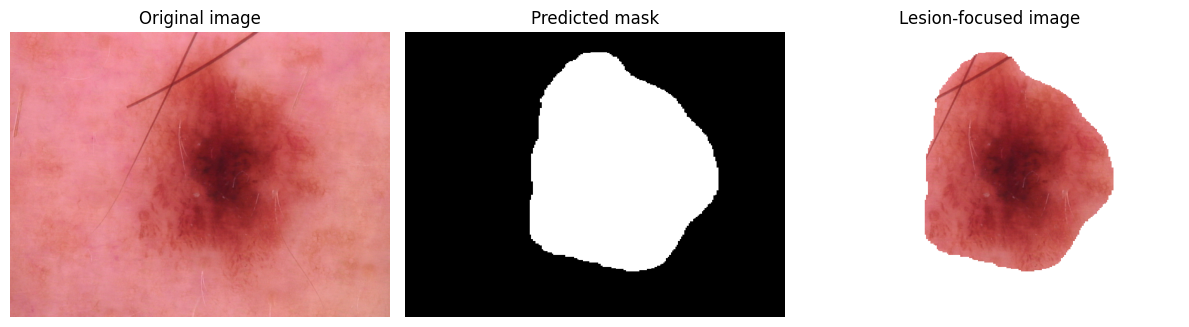

In [11]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_np, cmap="gray")
plt.title("Predicted mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(lesion_focused_img)
plt.title("Lesion-focused image")
plt.axis("off")

plt.tight_layout()
plt.show()

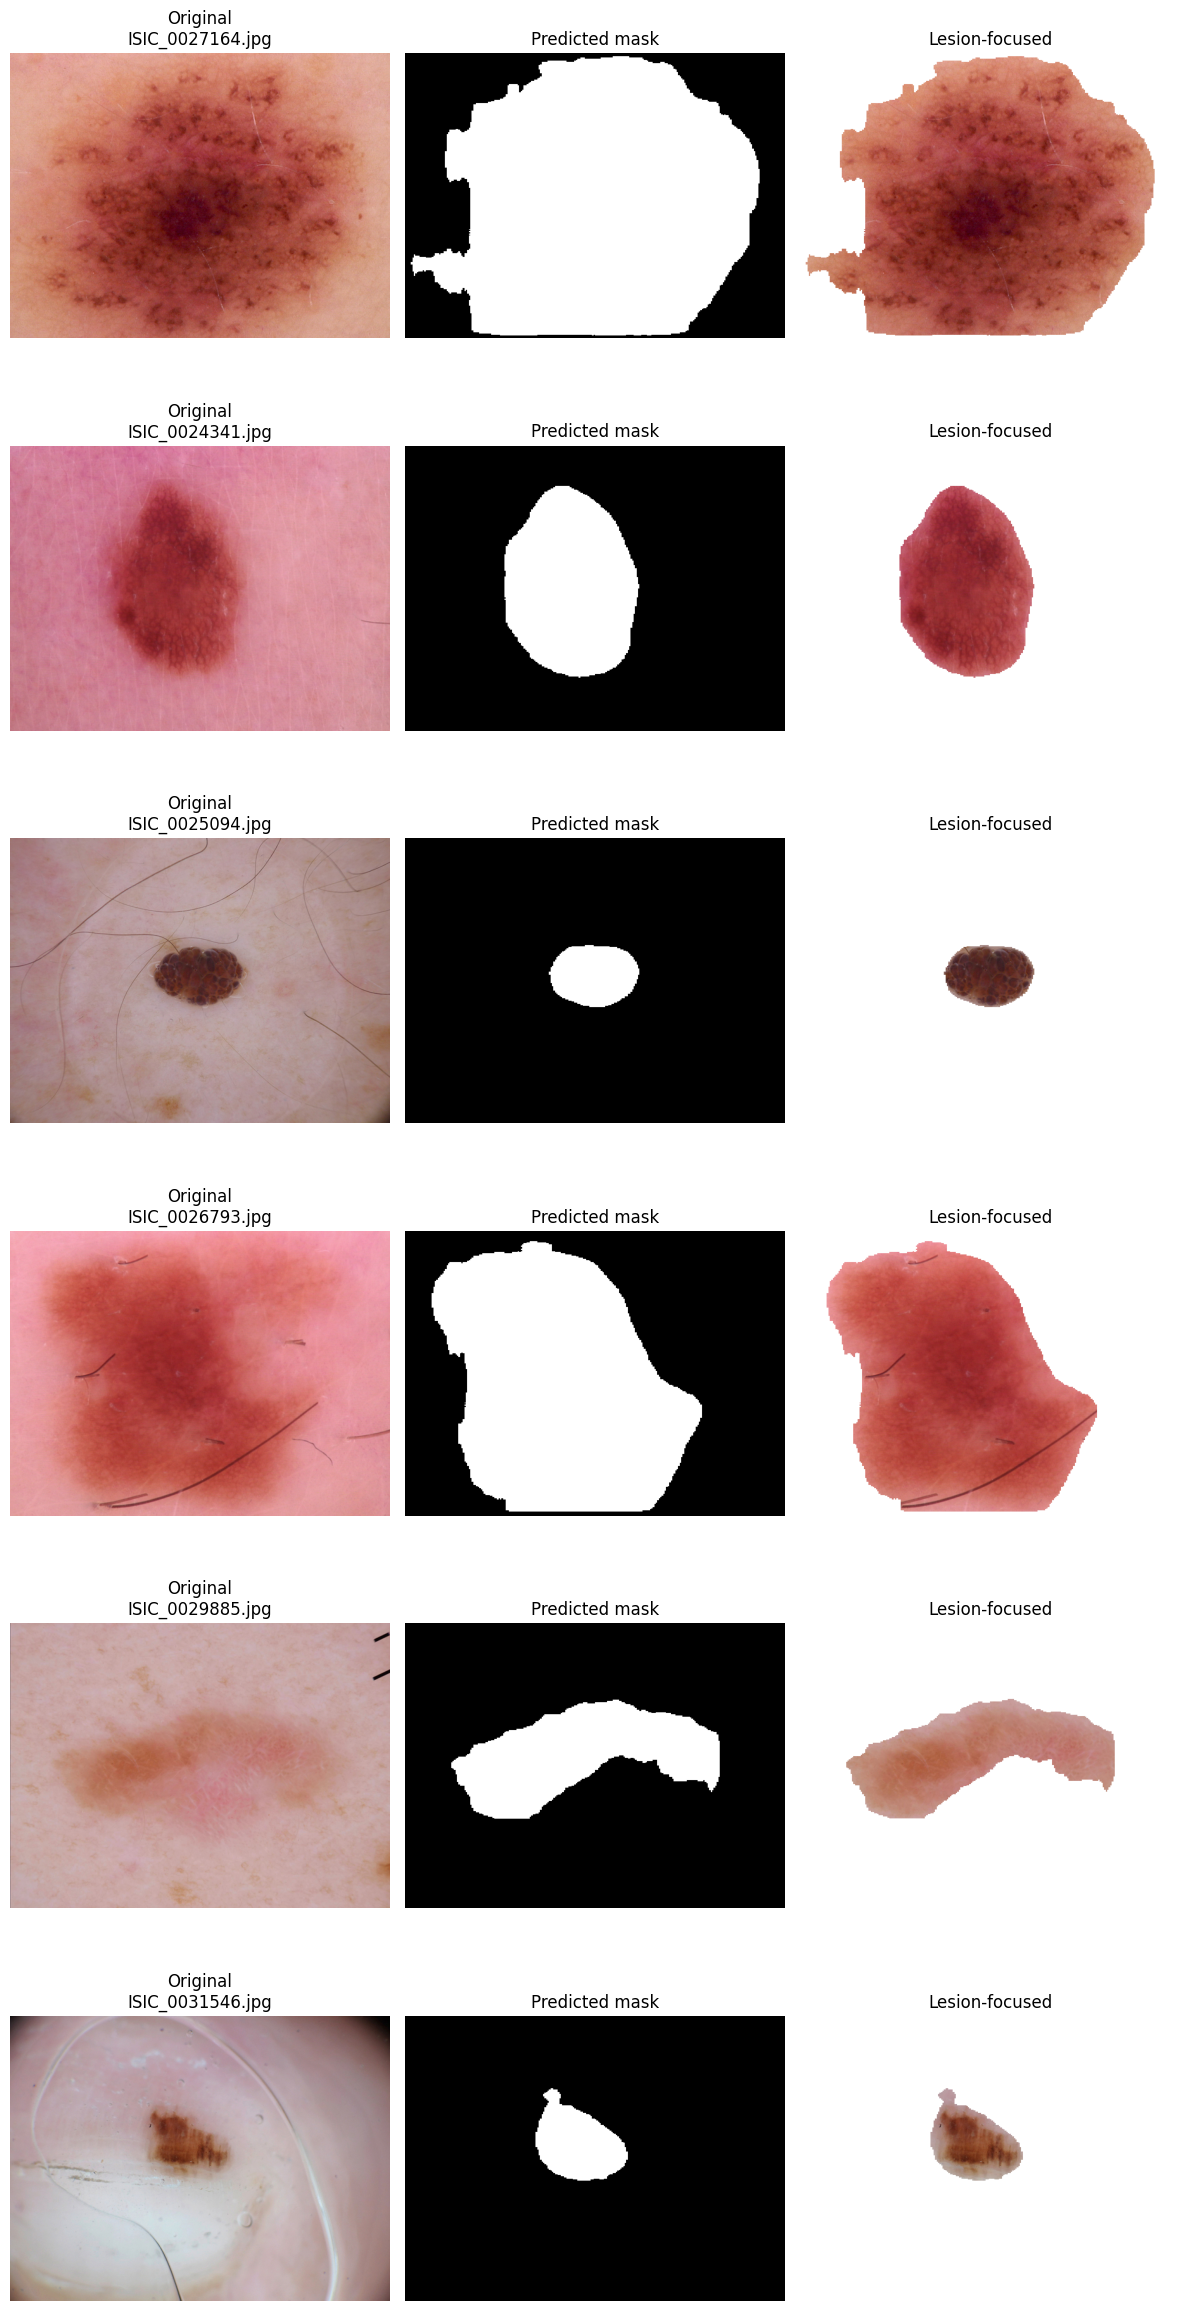

In [12]:
import random

sample_indices = random.sample(range(len(image_files)), 6)

plt.figure(figsize=(12, 4 * len(sample_indices)))

for row, idx in enumerate(sample_indices):
    image_name = image_files[idx]
    image_path = os.path.join(image_dir, image_name)

    image = Image.open(image_path).convert("RGB")
    original_size = image.size
    image_np = np.array(image).astype(np.uint8)

    image_tensor = image_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(image_tensor)
        probs = torch.sigmoid(logits)
        raw_mask = (probs > 0.5).float()

    raw_mask_np = raw_mask[0, 0].cpu().numpy()
    cleaned_mask_np = clean_binary_mask(raw_mask_np)

    mask_img = Image.fromarray((cleaned_mask_np * 255).astype(np.uint8))
    mask_img = mask_img.resize(original_size, resample=Image.NEAREST)

    mask_np = np.array(mask_img) / 255.0
    mask_np = mask_np.astype(np.float32)
    mask_3d = mask_np[:, :, None]

    white_background = np.ones_like(image_np) * 255
    lesion_focused_np = image_np * mask_3d + white_background * (1 - mask_3d)
    lesion_focused_np = lesion_focused_np.astype(np.uint8)

    plt.subplot(len(sample_indices), 3, 3*row + 1)
    plt.imshow(image)
    plt.title(f"Original\n{image_name}")
    plt.axis("off")

    plt.subplot(len(sample_indices), 3, 3*row + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Predicted mask")
    plt.axis("off")

    plt.subplot(len(sample_indices), 3, 3*row + 3)
    plt.imshow(lesion_focused_np)
    plt.title("Lesion-focused")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
output_dir = "/content/lesion_focused"
mask_output_dir = "/content/predicted_masks"

os.makedirs(output_dir, exist_ok=True)
os.makedirs(mask_output_dir, exist_ok=True)

print("Lesion-focused images will be saved locally to:", output_dir)
print("Predicted masks will be saved locally to:", mask_output_dir)

Lesion-focused images will be saved locally to: /content/lesion_focused
Predicted masks will be saved locally to: /content/predicted_masks


In [15]:
from tqdm import tqdm

model.eval()

for image_name in tqdm(image_files):
    image_path = os.path.join(image_dir, image_name)

    image = Image.open(image_path).convert("RGB")
    original_size = image.size
    image_np = np.array(image).astype(np.uint8)

    image_tensor = image_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(image_tensor)
        probs = torch.sigmoid(logits)
        raw_mask = (probs > 0.5).float()

    raw_mask_np = raw_mask[0, 0].cpu().numpy()
    cleaned_mask_np = clean_binary_mask(raw_mask_np)

    mask_img = Image.fromarray((cleaned_mask_np * 255).astype(np.uint8))
    mask_img = mask_img.resize(original_size, resample=Image.NEAREST)

    mask_np = np.array(mask_img).astype(np.float32) / 255.0
    mask_3d = mask_np[:, :, None]

    white_background = np.ones_like(image_np) * 255
    lesion_focused_np = image_np * mask_3d + white_background * (1 - mask_3d)
    lesion_focused_np = lesion_focused_np.astype(np.uint8)

    lesion_focused_img = Image.fromarray(lesion_focused_np)

    lesion_focused_path = os.path.join(output_dir, image_name)
    lesion_focused_img.save(lesion_focused_path)

    mask_name = image_name.replace(".jpg", "_mask.png")
    mask_path = os.path.join(mask_output_dir, mask_name)
    mask_img.save(mask_path)

100%|██████████| 10015/10015 [06:42<00:00, 24.87it/s]


In [16]:
!zip -r -q /content/lesion_focused.zip /content/lesion_focused
!zip -r -q /content/predicted_masks.zip /content/predicted_masks
!cp /content/lesion_focused.zip "/content/drive/MyDrive/CS289A/project/"
!cp /content/predicted_masks.zip "/content/drive/MyDrive/CS289A/project/"

In [19]:
print("Number of original images:", len(image_files))
print("Number of lesion-focused images:", len(os.listdir("/content/lesion_focused")))
print("Number of predicted masks:", len(os.listdir("/content/predicted_masks")))

Number of original images: 10015
Number of lesion-focused images: 10015
Number of predicted masks: 10015


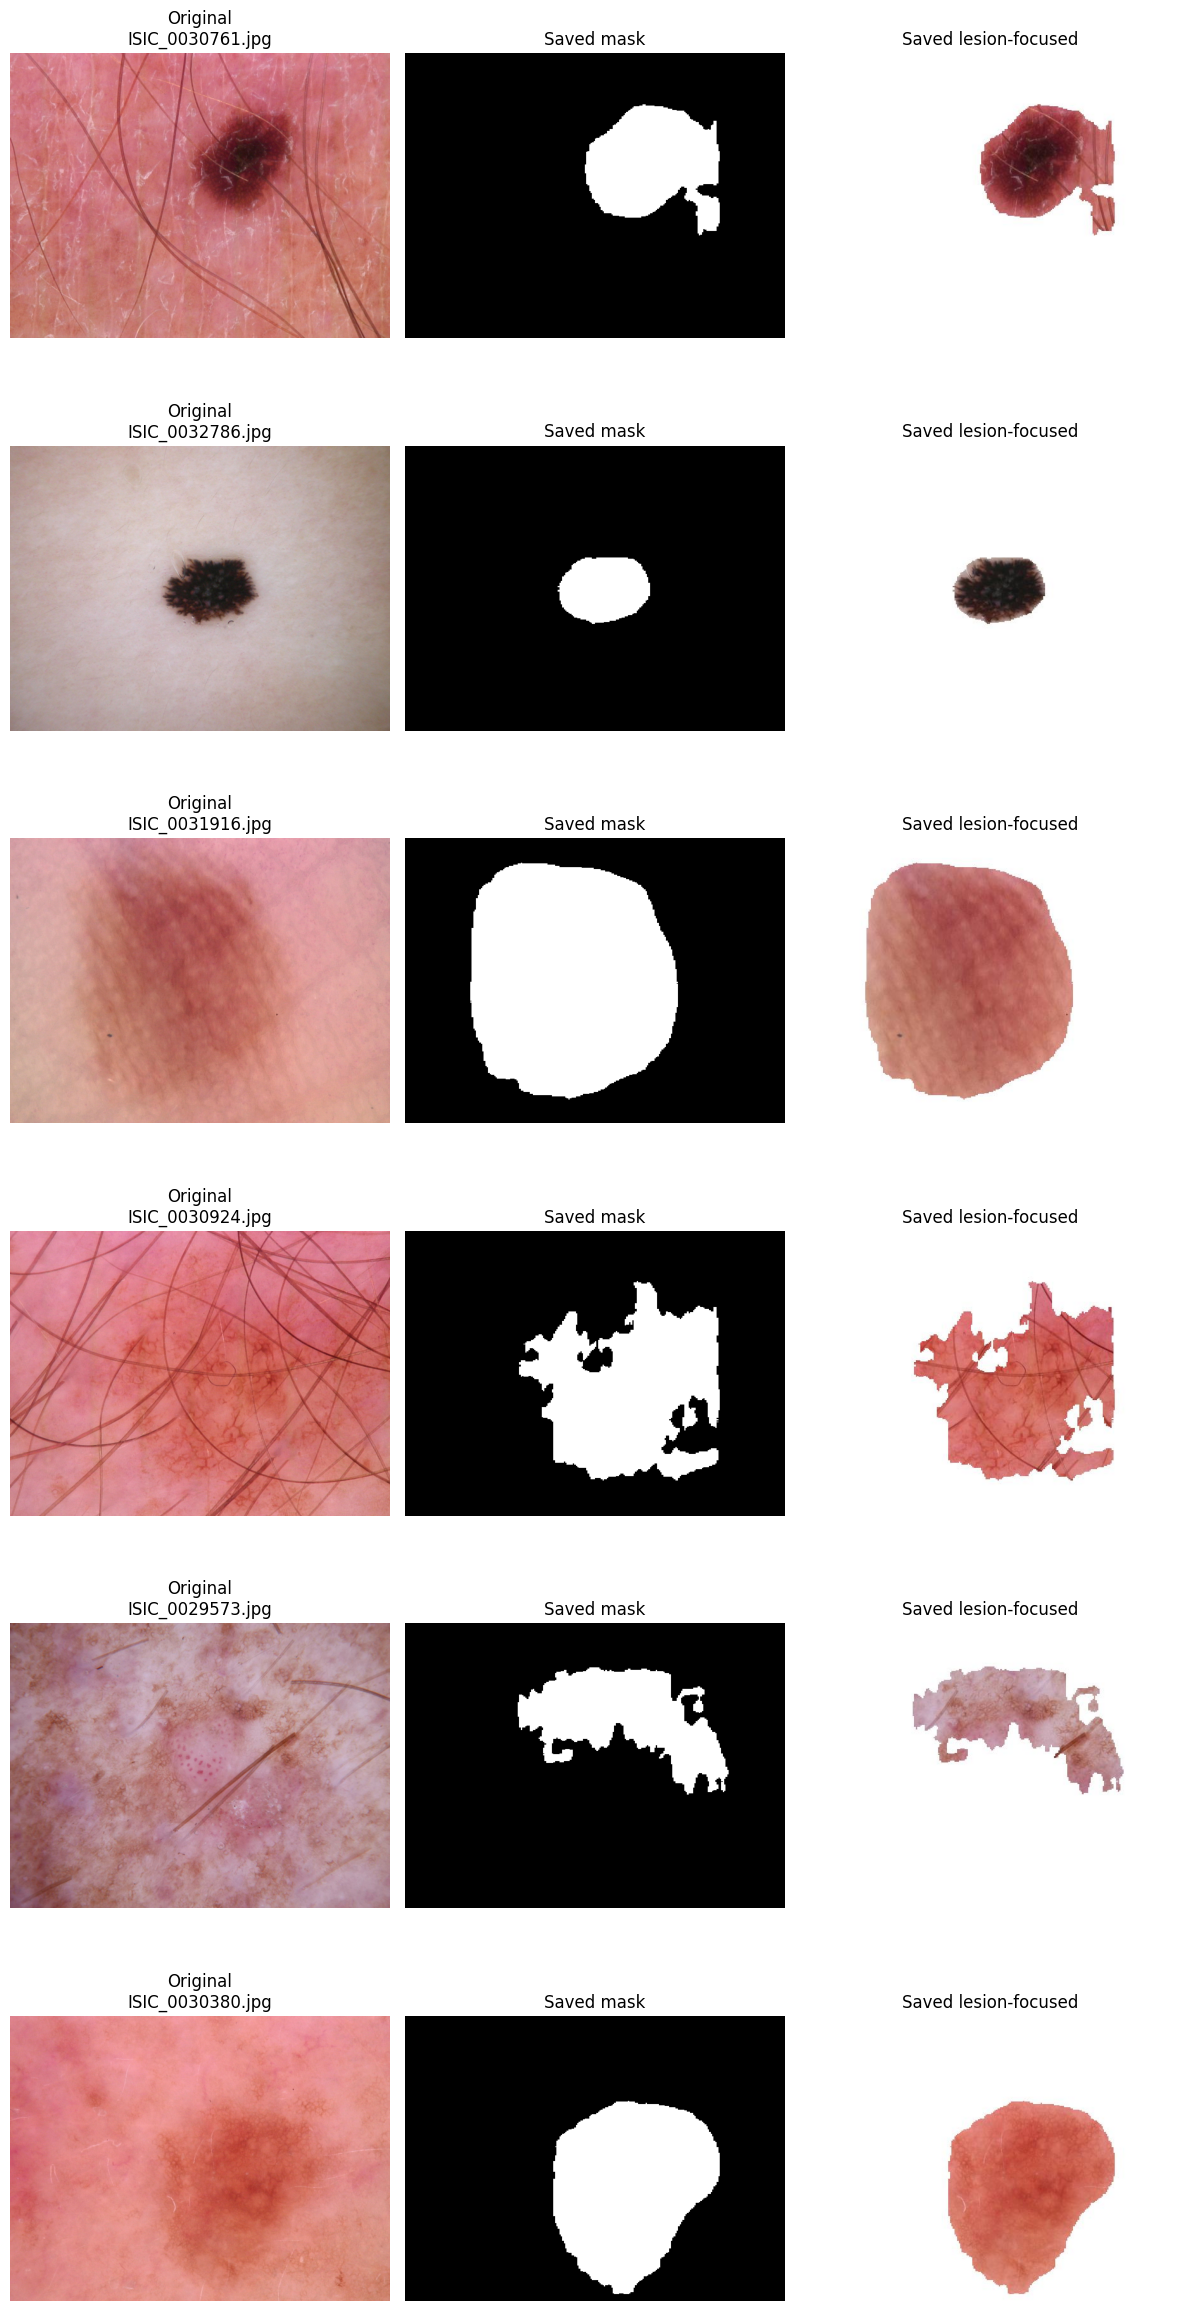

In [20]:
import random

focused_dir = "/content/lesion_focused"
saved_mask_dir = "/content/predicted_masks"

sample_names = random.sample(image_files, 6)

plt.figure(figsize=(12, 4 * len(sample_names)))

for row, image_name in enumerate(sample_names):
    original_path = os.path.join(image_dir, image_name)
    focused_path = os.path.join(focused_dir, image_name)
    mask_name = image_name.replace(".jpg", "_mask.png")
    mask_path = os.path.join(saved_mask_dir, mask_name)

    original_img = Image.open(original_path).convert("RGB")
    mask_img = Image.open(mask_path).convert("L")
    focused_img = Image.open(focused_path).convert("RGB")

    plt.subplot(len(sample_names), 3, 3*row + 1)
    plt.imshow(original_img)
    plt.title(f"Original\n{image_name}")
    plt.axis("off")

    plt.subplot(len(sample_names), 3, 3*row + 2)
    plt.imshow(mask_img, cmap="gray")
    plt.title("Saved mask")
    plt.axis("off")

    plt.subplot(len(sample_names), 3, 3*row + 3)
    plt.imshow(focused_img)
    plt.title("Saved lesion-focused")
    plt.axis("off")

plt.tight_layout()
plt.show()